In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Dirichlet
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


# =========================================
# 1. Dirichlet Sampler
# =========================================
class DirichletSampler:
    def __init__(self, alpha):
        self.alpha = torch.tensor(alpha, dtype=torch.float)
        self.dist = Dirichlet(self.alpha)

    def sample(self):
        return self.dist.rsample()

# =========================================
# 2. ReinMax / Straight-Through Estimator
# =========================================
class ReinMaxSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, logits):
        probs = F.softmax(logits, dim=-1)
        idx = probs.argmax(dim=-1)
        one_hot = F.one_hot(idx, num_classes=logits.size(-1)).type_as(logits)
        ctx.save_for_backward(probs)
        return one_hot

    @staticmethod
    def backward(ctx, grad_output):
        (probs,) = ctx.saved_tensors
        return grad_output * probs * (1 - probs)

reinforce_max = ReinMaxSTE.apply

# =========================================
# 3. Choice Block & Cell Definition
# =========================================
class ChoiceBlock(nn.Module):
    def __init__(self, ops, dropout_p=0.0):
        super().__init__()
        self.ops = nn.ModuleList(ops)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, x, logits):
        mask = reinforce_max(logits)
        for i, op in enumerate(self.ops):
            if mask[i] > 0:
                return self.dropout(op(x))
        return x

class Cell(nn.Module):
    def __init__(self, C, dropout_p=0.2, num_nodes=3):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_edges = sum(2 + i for i in range(num_nodes + 1))
        self.blocks = nn.ModuleList([
            ChoiceBlock([
                nn.Sequential(nn.Conv2d(C, C, 3, padding=1, groups=C), nn.Conv2d(C, C, 1)),
                nn.Sequential(nn.Conv2d(C, C, 5, padding=2, groups=C), nn.Conv2d(C, C, 1)),
                nn.Sequential(nn.MaxPool2d(3, stride=1, padding=1), nn.Conv2d(C, C, 1)),
                nn.Identity()
            ], dropout_p=dropout_p)
            for _ in range(self.num_edges)
        ])

    def forward(self, s0, s1, logits):
        states = [s0, s1]
        offset = 0
        for _ in range(self.num_nodes):
            nb = len(states)
            node = sum(self.blocks[offset + j](h, logits[offset + j]) for j, h in enumerate(states))
            states.append(node)
            offset += nb
        return states[-1]

# =========================================
# 4. HyperNetwork
# =========================================
class HyperNetwork(nn.Module):
    def __init__(self, num_blocks, num_ops, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_blocks * num_ops)
        self.num_blocks = num_blocks
        self.num_ops = num_ops
        self.dropout = nn.Dropout(0.2)

    def forward(self, lambda_vec):
        x = F.relu(self.fc1(lambda_vec))
        x = self.dropout(x)
        logits = self.fc2(x)
        return logits.view(self.num_blocks, self.num_ops)

# =========================================
# 5. SuperNetwork (Classification Only)
# =========================================
class SuperNetwork(nn.Module):
    def __init__(self, C=16, num_cells=4, dropout_p=0.2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, C, 3, stride=2, padding=1),
            nn.BatchNorm2d(C), nn.ReLU(),
            nn.Dropout(dropout_p)
        )
        self.cells = nn.ModuleList([Cell(C, dropout_p) for _ in range(num_cells)])
        self.cls_head = nn.Sequential(
            nn.Dropout(dropout_p),
            nn.Linear(C, 10)
        )

    def forward(self, x, arch_logits):
        s0 = s1 = self.stem(x)
        offset = 0
        for cell in self.cells:
            logits = arch_logits[offset:offset + cell.num_edges]
            s2 = cell(s0, s1, logits)
            s0, s1 = s1, s2
            offset += cell.num_edges
        gap = F.adaptive_avg_pool2d(s2, 1).view(x.size(0), -1)
        return self.cls_head(gap)

# =========================================
# 6. MGDA Solver for 2 Tasks
# =========================================
def solve_mgda_weights(M, iters=50, lr=1e-1, device='cpu'):
    k = M.shape[0]
    alpha = torch.full((k,), 1.0/k, device=device)
    for _ in range(iters):
        grad_alpha = 2 * M @ alpha
        alpha = alpha - lr * grad_alpha
        u, _ = torch.sort(alpha, descending=True)
        cssv = torch.cumsum(u, dim=0) - 1
        n = torch.arange(1, k+1, device=device, dtype=cssv.dtype)
        mask = u * n > cssv
        rho = torch.nonzero(mask, as_tuple=False)[-1, 0]
        theta = cssv[rho] / (rho.float() + 1)
        alpha = torch.clamp(alpha - theta, min=0)
    return alpha

# =========================================
# 7. Training Loop (Classification + Size)
# =========================================
def train():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Data
    transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    cifar = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    train_set, _ = random_split(cifar, [45000, 5000])
    loader = DataLoader(train_set, batch_size=256, shuffle=True, num_workers=4)

    # Model & Search
    sampler = DirichletSampler([1.0, 0.1])  # cls vs size
    supernet = SuperNetwork().to(device)
    num_blocks = sum(c.num_edges for c in supernet.cells)
    num_ops = len(supernet.cells[0].blocks[0].ops)
    hypernet = HyperNetwork(num_blocks, num_ops).to(device)

    # Optimizers & Loss
    opt_w = torch.optim.SGD(supernet.parameters(), lr=0.025, momentum=0.9, weight_decay=3e-4)
    opt_theta = torch.optim.SGD(hypernet.parameters(), lr=0.01, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    # Precompute size counts
    op_counts = [[sum(p.numel() for p in op.parameters())
                  for op in block.ops]
                 for cell in supernet.cells for block in cell.blocks]
    counts = torch.tensor(op_counts, device=device, dtype=torch.float)
    max_size = sum(max(c) for c in op_counts)

    for epoch in range(200):
        supernet.train(); hypernet.train()
        lambda_vec = sampler.sample().to(device)

        # Weight update
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            arch_logits = hypernet(lambda_vec)
            out = supernet(x, arch_logits)
            loss_cls = criterion(out, y)
            loss_size = (reinforce_max(arch_logits) * counts).sum() / max_size
            loss = lambda_vec[0]*loss_cls + lambda_vec[1]*loss_size
            opt_w.zero_grad(); loss.backward(); opt_w.step()

        # Architecture update with MGDA
        # Compute grads for cls & size on one batch
        x, y = next(iter(loader))
        x, y = x.to(device), y.to(device)
        arch_logits = hypernet(lambda_vec)
        out = supernet(x, arch_logits)
        losses = [criterion(out, y), (reinforce_max(arch_logits)*counts).sum()/max_size]
        grads = []
        for l in losses:
            g = torch.autograd.grad(l, hypernet.parameters(), allow_unused=True)
            flat = torch.cat([(gi if gi is not None else torch.zeros_like(p)).flatten()
                               for gi, p in zip(g, hypernet.parameters())])
            grads.append(flat / (flat.norm()+1e-8))
        G = torch.stack(grads); M = G @ G.T
        alpha = solve_mgda_weights(M, device=device)
        comb = sum(alpha[i]*grads[i] for i in range(2))
        offset = 0
        for p in hypernet.parameters():
            num = p.numel()
            p.grad = comb[offset:offset+num].view_as(p)
            offset += num
        opt_theta.step()

        if epoch % 5 == 0:
            print(f"Epoch {epoch}: loss_cls={loss_cls:.4f}, loss_size={loss_size:.4f}")

    torch.save({'supernet': supernet.state_dict(), 'hypernet': hypernet.state_dict()}, 'checkpoint.pth')

if __name__ == "__main__":
    train()


Epoch 0: loss_cls=2.3216, loss_size=0.5478
Epoch 5: loss_cls=2.3037, loss_size=0.5382
Epoch 10: loss_cls=2.3027, loss_size=0.4784
Epoch 15: loss_cls=2.1017, loss_size=0.5361
Epoch 20: loss_cls=2.0766, loss_size=0.4639
Epoch 25: loss_cls=2.0245, loss_size=0.5561
Epoch 30: loss_cls=2.0933, loss_size=0.5274
Epoch 35: loss_cls=1.9108, loss_size=0.4539
Epoch 40: loss_cls=1.9256, loss_size=0.5436
Epoch 45: loss_cls=1.8679, loss_size=0.5062
Epoch 50: loss_cls=1.9648, loss_size=0.4892
Epoch 55: loss_cls=1.7732, loss_size=0.5403
Epoch 60: loss_cls=1.8361, loss_size=0.5490
Epoch 65: loss_cls=1.9795, loss_size=0.5573
Epoch 70: loss_cls=1.7654, loss_size=0.5357
Epoch 75: loss_cls=1.7634, loss_size=0.5507
Epoch 80: loss_cls=1.8018, loss_size=0.5428
Epoch 85: loss_cls=1.7974, loss_size=0.5656
Epoch 90: loss_cls=1.8510, loss_size=0.4896
Epoch 95: loss_cls=1.7161, loss_size=0.5880
Epoch 100: loss_cls=1.8950, loss_size=0.5191
Epoch 105: loss_cls=1.8709, loss_size=0.5199
Epoch 110: loss_cls=1.8825, loss

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
# from evaluation_code import evaluate  # assumes evaluation_code.py is in the same directory
# from main_training import SuperNetwork, HyperNetwork, DirichletSampler, Cell  # adjust import path as needed

# =========================================
# Pareto Front Visualization (Classification vs Model Size)
# =========================================

def is_pareto_efficient(costs):
    """
    Find the Pareto-efficient points in a set of points.
    costs: numpy array of shape (n_points, n_objectives), to minimize each column
    Returns boolean mask of Pareto-efficient points.
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1)
            is_efficient[i] = True
    return is_efficient

if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Load checkpoint
    chk = torch.load('checkpoint.pth', map_location=device)

    # Reconstruct models
    supernet = SuperNetwork().to(device)
    supernet.load_state_dict(chk['supernet'])

    num_blocks = sum(c.num_edges for c in supernet.cells)
    num_ops = len(supernet.cells[0].blocks[0].ops)
    hypernet = HyperNetwork(num_blocks, num_ops).to(device)
    hypernet.load_state_dict(chk['hypernet'])

    # Dirichlet sampler for cls vs size
    sampler = DirichletSampler([1.0, 0.1])

    # Recompute counts_tensor and max_size from the SuperNetwork definition
    op_counts = [
        [sum(p.numel() for p in op.parameters())
         for op in block.ops]
        for cell in supernet.cells
        for block in cell.blocks
    ]
    counts_tensor = torch.tensor(op_counts, device=device, dtype=torch.float)
    max_size = float(sum(max(c) for c in op_counts))

        # Sample architectures and evaluate for classification vs. size
    n_samples = 100
    metrics = []  # [accuracy, size_penalty]
    for _ in range(n_samples):
        lambda_vec = sampler.sample().to(device)
        arch_logits = hypernet(lambda_vec)
        res = evaluate(supernet, arch_logits, counts_tensor, max_size, device)
        metrics.append([res['cls_acc'], res['size_penalty']])

    metrics = np.array(metrics)
    # For Pareto, treat objectives: minimize cost1 = -accuracy, cost2 = size_penalty
    costs = np.stack([-metrics[:,0], metrics[:,1]], axis=1)
    pareto_mask = is_pareto_efficient(costs)


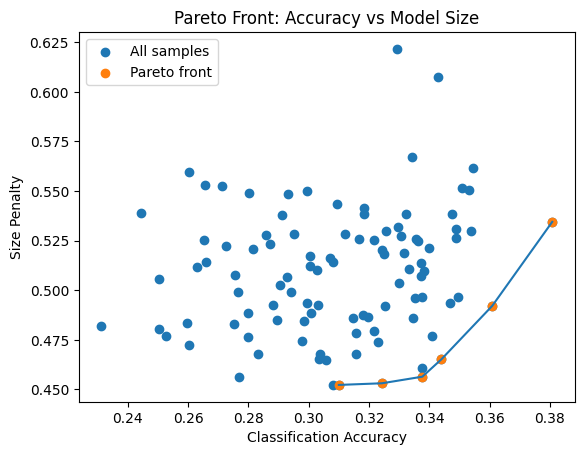

In [35]:
    # Plot Pareto front: Accuracy vs. Size Penalty
    plt.figure()
    plt.scatter(metrics[:, 0], metrics[:, 1], label='All samples')
    plt.scatter(metrics[pareto_mask, 0], metrics[pareto_mask, 1], label='Pareto front')
    # Sort Pareto points for connecting line
    front = metrics[pareto_mask]
    order = np.argsort(front[:, 0])
    plt.plot(front[order, 0], front[order, 1])
    plt.xlabel('Classification Accuracy')
    plt.ylabel('Size Penalty')
    plt.title('Pareto Front: Accuracy vs Model Size')
    # plt.gca().invert_yaxis()
    plt.legend()
    plt.show()

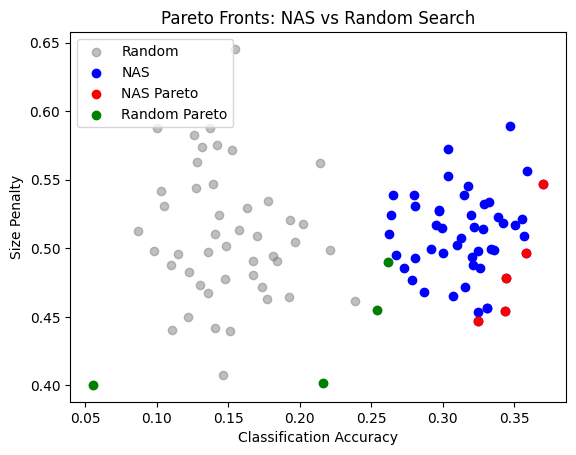

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os

# =========================================
# Pareto Front Visualization and Scratch Training
# =========================================

def is_pareto_efficient(costs):
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1)
            is_efficient[i] = True
    return is_efficient


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Load checkpoint
chk = torch.load('checkpoint.pth', map_location=device)

# Reconstruct networks
supernet = SuperNetwork().to(device)
supernet.load_state_dict(chk['supernet'])
num_blocks = sum(c.num_edges for c in supernet.cells)
num_ops = len(supernet.cells[0].blocks[0].ops)
hypernet = HyperNetwork(num_blocks, num_ops).to(device)
hypernet.load_state_dict(chk['hypernet'])

# Recompute size costs
op_counts = [[sum(p.numel() for p in op.parameters()) for op in block.ops]
                for cell in supernet.cells for block in cell.blocks]
counts_tensor = torch.tensor(op_counts, device=device, dtype=torch.float)
max_size = float(sum(max(c) for c in op_counts))

# Samplers
nas_sampler = DirichletSampler([1.0, 0.1])
rand_sampler = lambda: torch.randn(num_blocks, num_ops, device=device)

# Sample metrics
n_samples = 50
nas_metrics = []
rand_metrics = []
arch_nas = []
arch_rand = []
for _ in range(n_samples):
    lam = nas_sampler.sample().to(device)
    logits = hypernet(lam)
    res = evaluate(supernet, logits, counts_tensor, max_size, device)
    nas_metrics.append([res['cls_acc'], res['size_penalty']])
    arch_nas.append(logits.clone())

    logits_r = rand_sampler()
    res_r = evaluate(supernet, logits_r, counts_tensor, max_size, device)
    rand_metrics.append([res_r['cls_acc'], res_r['size_penalty']])
    arch_rand.append(logits_r.clone())

nas_metrics = np.array(nas_metrics)
rand_metrics = np.array(rand_metrics)

# Identify Pareto fronts
costs_n = np.stack([-nas_metrics[:,0], nas_metrics[:,1]], axis=1)
costs_r = np.stack([-rand_metrics[:,0], rand_metrics[:,1]], axis=1)
pareto_n = is_pareto_efficient(costs_n)
pareto_r = is_pareto_efficient(costs_r)

In [ ]:
# Plot both
plt.figure()
plt.scatter(rand_metrics[:,0], rand_metrics[:,1], c='gray', alpha=0.5, label='Random')
plt.scatter(nas_metrics[:,0], nas_metrics[:,1], c='blue', label='NAS')
plt.scatter(nas_metrics[pareto_n,0], nas_metrics[pareto_n,1], c='red', label='NAS Pareto')
plt.scatter(rand_metrics[pareto_r,0], rand_metrics[pareto_r,1], c='green', label='Random Pareto')
plt.xlabel('Classification Accuracy')
plt.ylabel('Size Penalty')
plt.title('Pareto Fronts: NAS vs Random Search')
plt.legend()
plt.show()

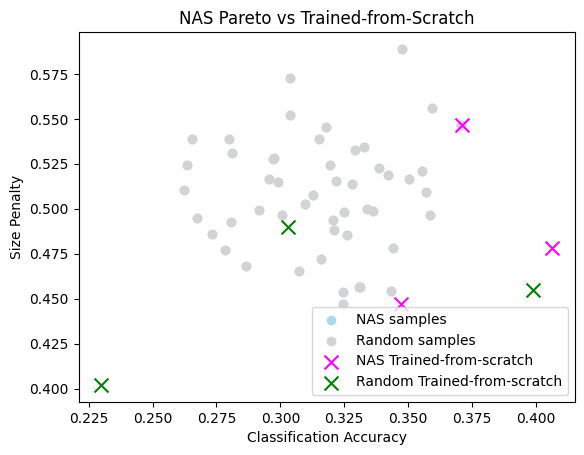

In [ ]:
def train_scratch(arch_logits, counts_tensor, max_size, device, epochs=50):
    # trains a fixed architecture defined by arch_logits
    # 1) extract chosen op indices per block
    arch_indices = arch_logits.argmax(dim=-1).tolist()
    C = 16
    num_cells = len(supernet.cells)  # uses loaded supernet to infer structure
    # Build a static network with selected ops only
    class StaticSuperNetwork(nn.Module):
        def __init__(self, C, num_cells, arch_indices):
            super().__init__()
            self.stem = supernet.stem  # reuse stem parameters
            # reconstruct cells with only chosen ops
            self.cells = nn.ModuleList()
            idx = 0
            for cell in supernet.cells:
                ops = []
                for block in cell.blocks:
                    choice = arch_indices[idx]
                    # take the selected op module (clone to avoid aliasing)
                    op = block.ops[choice]
                    ops.append(op)
                    idx += 1
                # each cell is sequence of these ops applied in DAG
                self.cells.append(nn.ModuleList(ops))
            self.cls_head = supernet.cls_head

        def forward(self, x, _):
            # ignore arch_logits, use static ops
            s0 = s1 = self.stem(x)
            idx = 0
            for cell_ops in self.cells:
                # static cell: treat each op as connecting current s0->node, s1->node sequentially
                # we assume two-input DAG with num_nodes= len(cell_ops)-1
                node = 0
                # sum of all op outputs on s0 and s1
                out = cell_ops[idx](s1)
                idx += 1
                s0, s1 = s1, out
            gap = F.adaptive_avg_pool2d(s1, 1).view(x.size(0), -1)
            return self.cls_head(gap)

    model = StaticSuperNetwork(C, num_cells, arch_indices).to(device)
    opt = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9, weight_decay=1e-4)
    criterion = torch.nn.CrossEntropyLoss()

    # Data
    transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    cifar = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    train_set, _ = torch.utils.data.random_split(cifar, [45000, 5000])
    loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=4)

    for ep in range(epochs):
        model.train()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x, None)
            loss = criterion(out, y)
            opt.zero_grad(); loss.backward(); opt.step()
    # evaluate final accuracy
    res = evaluate(model, arch_logits, counts_tensor, max_size, device)
    return res['cls_acc']


num_samples = 3
num_epochs = 30

# Select top 5 NAS Pareto architectures and train from scratch
idx_n = np.where(pareto_n)[0][:num_samples]
idx_r = np.where(pareto_r)[0][:num_samples]

nas_trained_metrics = []
rand_trained_metrics = []

for i in idx_n:
    nas_acc = train_scratch(arch_nas[i], counts_tensor, max_size, device, epochs=num_epochs)
    one_hot = torch.nn.functional.one_hot(arch_nas[i].argmax(dim=-1), num_ops).float().to(device)
    size_p = (one_hot * counts_tensor).sum().item() / max_size
    nas_trained_metrics.append([nas_acc, size_p])

for i in idx_r:
    rand_acc = train_scratch(arch_rand[i], counts_tensor, max_size, device, epochs=num_epochs)
    one_hot = torch.nn.functional.one_hot(arch_rand[i].argmax(dim=-1), num_ops).float().to(device)
    size_p = (one_hot * counts_tensor).sum().item() / max_size
    rand_trained_metrics.append([rand_acc, size_p])

nas_trained_metrics = np.array(nas_trained_metrics)
rand_trained_metrics = np.array(rand_trained_metrics)

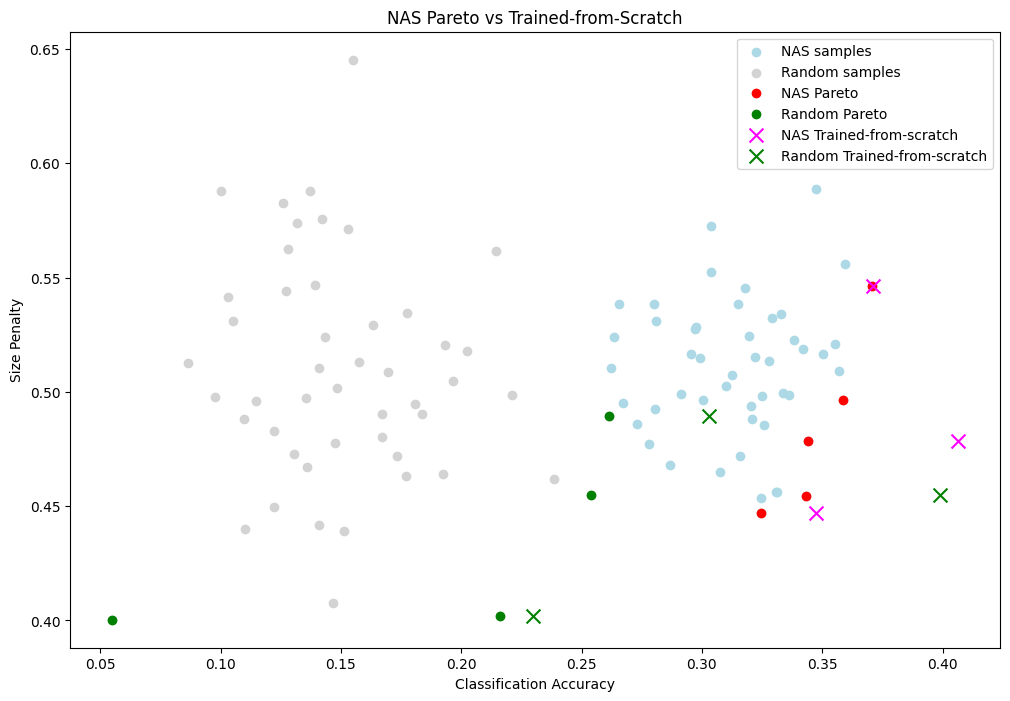

In [57]:
# Plot with true trained points
plt.figure(figsize=(12,8))
plt.scatter(nas_metrics[:,0], nas_metrics[:,1], c='lightblue', label='NAS samples')
plt.scatter(rand_metrics[:,0], rand_metrics[:,1], c='lightgray', label='Random samples')
plt.scatter(nas_metrics[pareto_n,0], nas_metrics[pareto_n,1], c='red', label='NAS Pareto')
plt.scatter(rand_metrics[pareto_r,0], rand_metrics[pareto_r,1], c='green', label='Random Pareto')

plt.scatter(nas_trained_metrics[:,0], nas_trained_metrics[:,1], c='magenta', marker='x', s=100, label='NAS Trained-from-scratch')
plt.scatter(rand_trained_metrics[:,0], rand_trained_metrics[:,1], c='green', marker='x', s=100, label='Random Trained-from-scratch')

plt.xlabel('Classification Accuracy')
plt.ylabel('Size Penalty')
plt.title('NAS Pareto vs Trained-from-Scratch')
plt.legend()
plt.show()